In [101]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !pip install -r requirements.txt
    # Uninstall CPU jax/jaxlib if present
    # !pip uninstall -y jax jaxlib

    # # Install GPU-enabled JAX (choose the right cuda extra for your Colab)
    # # Try cuda12 first (common in Colab recently):
    # !pip install -U "jax[cuda12]"


In [102]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
from utils.load_matlab import load_mat_v73, flatten_cell
import torch.nn.functional as F
import h5py
import math
import torch.nn as nn

In [103]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
CUDA available: False


## Model Base Class for simulation and fitting

In [104]:
# ----------------------------
# Utilities
# ----------------------------
def convolveStimulusWithBasis_torch(stimulus: torch.Tensor, basis: torch.Tensor, add_ones: bool = True):
    """
    stimulus: [T] or [T,Npix]
    basis:    [L,P]
    returns X: [T, Npix*P + (1 if add_ones else 0)]
    """
    if stimulus.ndim == 1:
        stimulus = stimulus[:, None]  # [T, Npix]
    T, Npix = stimulus.shape
    L, P = basis.shape

    x = stimulus.transpose(0, 1).unsqueeze(1)          # [Npix, 1, T]
    w = basis.transpose(0, 1).flip(1).unsqueeze(1)     # [P, 1, L]

    y = F.conv1d(F.pad(x, (L - 1, 0)), w)              # [Npix, P, T]
    X = y.permute(2, 0, 1).reshape(T, Npix * P)        # [T, Npix*P]

    if add_ones:
        ones = torch.ones(T, 1, device=X.device, dtype=X.dtype)
        X = torch.cat([X, ones], dim=1)
    return X


In [105]:
def logOnePlusExpX_torch(x, maxG):
    """
    MATLAB logOnePlusExpX.m:
      if x <= -30: f = 1e-15
      elif x >= maxG: f = x
      else: f = log(1+exp(x))
    """
    x = torch.as_tensor(x)
    maxG = torch.as_tensor(maxG, device=x.device, dtype=x.dtype)
    while maxG.ndim < x.ndim:
        maxG = maxG.unsqueeze(0)

    f = x.clone()
    lessT = x <= -30.0
    greaterT = x >= maxG
    toFit = (~lessT) & (~greaterT)

    f[toFit] = F.softplus(x[toFit])
    f[lessT] = 1e-15
    return f

# def get_voltage_exp_recurrence(gs, E_s, g_l, E_l, V0, dt_s, eps=1e-12):
#     g_tot = g_l + gs.sum(dim=1)                         # [T]
#     I_tot = E_l * g_l + gs @ E_s                        # [T]
#     V_inf = I_tot / (g_tot + eps)                       # [T]
#     a = torch.exp(-dt_s * g_tot)                        # [T]

#     V = torch.empty_like(g_tot)
#     v_prev = torch.as_tensor(V0, device=gs.device, dtype=gs.dtype)
#     for t in range(gs.shape[0]):
#         v_prev = a[t] * v_prev + (1.0 - a[t]) * V_inf[t]
#         V[t] = v_prev
#     return V

def get_voltage_exp_recurrence(gs, E_s, g_l, E_l, V0, dt_s, eps=1e-12, chunk=256):
    """
    Exact same recurrence as the for-loop:
        v <- a[t]*v + (1-a[t])*Vinf[t]
    but computed in chunks to avoid Python-per-timestep overhead
    AND avoid global cumprod underflow.
    
    """
    g_tot = g_l + gs.sum(dim=1)                    # [T]
    I_tot = E_l * g_l + gs @ E_s                   # [T]
    V_inf = I_tot / (g_tot + eps)                  # [T]
    a = torch.exp(-dt_s * g_tot)                   # [T]
    b = (1.0 - a) * V_inf                          # [T]
    #does b/a so may be unstable. 
    T = a.shape[0]
    V = torch.empty_like(a)

    v_prev = torch.as_tensor(V0, device=gs.device, dtype=gs.dtype)

    for start in range(0, T, chunk):
        end = min(start + chunk, T)
        a_c = a[start:end]                         # [C]
        b_c = b[start:end]                         # [C]

        # Within-chunk closed form (safe because chunk is small):
        A = torch.cumprod(a_c, dim=0)              # [C], won't underflow for small C
        s = torch.cumsum(b_c / (A + eps), dim=0)   # [C]
        V_c = A * (v_prev + s)                     # [C]

        V[start:end] = V_c
        v_prev = V_c[-1]

    return V

def firingRateNonlinearity(V_t, alpha, mu, beta):
    return alpha * F.softplus((V_t - mu) / beta)

# Stable truncated-Poisson/Bernoulli-per-bin NLL
def poisson_nll_truncated_from_spike_bins(rate: torch.Tensor,
                                         spkTimes_bins: torch.Tensor,
                                         binsize_s: float,
                                         eps: float = 1e-8) -> torch.Tensor:
    lam = rate * binsize_s
    ll = -lam

    spk_idx = torch.as_tensor(spkTimes_bins, device=rate.device, dtype=torch.long)
    spk_idx = spk_idx[(spk_idx >= 0) & (spk_idx < lam.shape[0])]
    if spk_idx.numel() > 0:
        spk_idx = torch.unique(spk_idx)
        p_spike = (-torch.expm1(-lam[spk_idx])).clamp_min(eps)  # stable 1-exp(-lam)
        ll = ll.clone()
        ll[spk_idx] = torch.log(p_spike)

    return -ll.sum()

# ----------------------------
# Model
# ----------------------------
class CBEM(nn.Module):
    def __init__(self, binsize_s: float,
                 gbar_exc: float = 80.0, 
                 gbar_inh: float = 80.0,
                 E_l: float = -60.0, 
                 g_l: float = 200.0, 
                 V0: float | None = None,
                 alpha: float = 90.0, 
                 beta: float = 1.67, 
                 mu: float = -53.0,
                 add_ones: bool = True):
        super().__init__()
        self.binsize_s = float(binsize_s)
        self.add_ones = bool(add_ones)

        self.register_buffer("E_s", torch.tensor([0.0, -80.0], dtype=torch.float32))
        self.register_buffer("E_l", torch.tensor(E_l, dtype=torch.float32))
        self.register_buffer("g_l", torch.tensor(g_l, dtype=torch.float32))
        self.register_buffer("V0", torch.tensor(E_l if V0 is None else V0, dtype=torch.float32))
        self.register_buffer("gbar", torch.tensor([gbar_exc, gbar_inh], dtype=torch.float32))

        self.register_buffer("alpha", torch.tensor(alpha, dtype=torch.float32))
        self.register_buffer("beta",  torch.tensor(beta,  dtype=torch.float32))
        self.register_buffer("mu",    torch.tensor(mu,    dtype=torch.float32))

        self.B_cond = None  # lazy nn.Parameter

    def _maybe_init_B_cond_from_D(self, D: int, device, dtype):
        if self.B_cond is None:
            self.B_cond = nn.Parameter(torch.zeros(D, 2, device=device, dtype=dtype))

    def conductances_from_X(self, X_cond: torch.Tensor) -> torch.Tensor:
        x = X_cond @ self.B_cond                          # [T,2]
        return logOnePlusExpX_torch(x, self.gbar.to(x.device, x.dtype))

    def voltage(self, gs: torch.Tensor) -> torch.Tensor:
        # run voltage in float64 for stability, then cast back
        gs64 = gs.to(torch.float64)

        E_s64 = self.E_s.to(device=gs.device, dtype=torch.float64)
        E_l64 = self.E_l.to(device=gs.device, dtype=torch.float64)
        g_l64 = self.g_l.to(device=gs.device, dtype=torch.float64)
        V064  = self.V0.to(device=gs.device, dtype=torch.float64)

        V64 = get_voltage_exp_recurrence(
            gs64,
            E_s64,
            g_l=g_l64,
            E_l=E_l64,
            V0=V064,
            dt_s=float(self.binsize_s),
        )
        return V64.to(gs.dtype)
    
    def forward(self, X_cond: torch.Tensor, window=None):
        # X_cond is already the design matrix [T, D]
        if window is not None:
            window = torch.as_tensor(window, device=X_cond.device, dtype=torch.long)
            X_cond = X_cond[window]

        self._maybe_init_B_cond_from_D(X_cond.shape[1], device=X_cond.device, dtype=X_cond.dtype)

        gs = self.conductances_from_X(X_cond)             # [T,2]
        V  = self.voltage(gs)                             # [T]
        rate = 1e-4 + firingRateNonlinearity(V, self.alpha, self.mu, self.beta)  # [T]
        return rate, {"V": V, "gs": gs}
    
    @torch.no_grad()
    def simulateSpikeTrains(
        self,
        X_cond: torch.Tensor,
        Y_init: torch.Tensor,
        N: int | None = None,
        seed: int = 0,
        eps: float = 0.0,
    ) -> torch.Tensor:
        """
        Simulates spike trains using Bernoulli-per-bin approximation to Poisson:
            p_t = 1 - exp(-rate_t * binsize_s)

        Args:
          X_cond: [T, D] design matrix for conductances (already built / cached)
          Y_init: [T0, N] or [T0, 1] initial spikes (0/1). Used only to seed first T0 bins.
          N:      number of simulations. If Y_init has 1 column, it will be broadcast to N.
          seed:   RNG seed
          eps:    optional clamp for probabilities (0 means no clamp)

        Returns:
          sps: [T, N] spikes in {0,1} (float tensor)
        """
        device = X_cond.device
        dtype  = X_cond.dtype

        Y_init = torch.as_tensor(Y_init, device=device, dtype=dtype)
        if Y_init.ndim == 1:
            Y_init = Y_init[:, None]  # [T0,1]
        T0, N0 = Y_init.shape

        if N is None:
            N = N0
        if not (N == N0 or N0 == 1):
            raise ValueError("Invalid N: must match Y_init.shape[1] or Y_init must have 1 column")

        if N0 == 1 and N > 1:
            Y_init = Y_init.expand(T0, N).contiguous()

        T = X_cond.shape[0]
        if T0 >= T:
            raise ValueError("Y_init must be shorter than total T (T0 < T).")

        # Get stimulus-driven rate once: [T]
        rate, aux = self.forward(X_cond)          # rate in Hz, shape [T]
        lam = rate * float(self.binsize_s)        # expected spikes per bin, [T]
        p = (-torch.expm1(-lam))                  # stable 1-exp(-lam), [T]
        if eps > 0:
            p = p.clamp(min=eps, max=1.0 - eps)
        else:
            p = p.clamp(min=0.0, max=1.0)

        # Sample N spike trains
        gen = torch.Generator(device=device)
        gen.manual_seed(int(seed))
        rs = torch.rand((T, N), generator=gen, device=device, dtype=dtype)

        sps = (rs < p[:, None]).to(dtype)         # [T,N]
        sps[:T0, :] = Y_init                      # overwrite seed segment
        return sps
    
  

## Stim

In [106]:
# from utils.stim_utils import generate_1_f_noise, plot_stim
# beta= 0
# mean_intensity = 0.15
# desired_contrast = 0.3
# stim_duration = 7
# trials = 1

# dt = 1e-4
# frame_rate = int(1/dt)
# # dt_stim = 1/frame_rate

# frame_dwell = 1
# tau = 10

# all_noise = []
# all_contrast = []
# for trial in range(trials):
#     noise, contrast = generate_1_f_noise(
#         beta, frame_rate * stim_duration, frame_rate,
#         frame_dwell, mean_intensity, desired_contrast,
#         noise_seed=trial)
#     all_noise.append(noise)
#     all_contrast.append(contrast)

# noise_t = np.concatenate(all_noise)
# stimulus = np.concatenate(all_contrast)
# stim = np.array(all_contrast)

# plot_stim(noise_t=noise_t, contrast_mat=stim,
#           beta=beta,
#           mean_intensity=mean_intensity,
#           desired_contrast=desired_contrast,
#           tau=10, frame_rate=frame_rate, figsize=(16,7))
# print(stimulus.shape, stim.shape)

In [107]:
# load stimulus and spike times from the matlab file
filename = "Data/example.mat"
with h5py.File(filename, "r") as f:
    stimulus  = np.array(list(f["X"]))[0]
    CBEM_True = np.array(list(f["CBEM_true"]))
cbem_data = load_mat_v73("Data/example.mat", "CBEM_true")
dt      = float(cbem_data["dt"])
E_l     = float(cbem_data["E_l"])
initV   = float(cbem_data["initV"])
g_l     = float(cbem_data["g_l"])
log_g_l = float(cbem_data["log_g_l"])

E_s     = np.array(cbem_data["E_s"]).squeeze()
g_s_bar = np.array(cbem_data["g_s_bar"]).squeeze()

stimBasisVectors = np.array(cbem_data["stimBasisVectors"]).T
stimNumBasisVectors = int(np.squeeze(cbem_data["stimNumBasisVectors"]))
spkHistBasisVectors = np.array(cbem_data["spkHistBasisVectors"])

k_s_list = [np.array(x).squeeze() for x in flatten_cell(cbem_data["k_s"])]
print(len(k_s_list), [ks.shape for ks in k_s_list])

3 [(11,), (11,), ()]


In [108]:
k_e = np.array(k_s_list[0]).squeeze()
k_i = np.array(k_s_list[1]).squeeze()
print(k_e.shape, k_i.shape)
print(k_e.shape, k_i.shape)
# MATLAB: k_s{1}(1:stimNumBasisVectors)
k_e = k_e[:stimNumBasisVectors]   # Python is 0-indexed
k_i = k_i[:stimNumBasisVectors]
L = stimBasisVectors.shape[0]

(11,) (11,)
(11,) (11,)


In [109]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

# Observation Model

In [110]:
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float32, device=device)
B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float32, device=device)

X_full = convolveStimulusWithBasis_torch(stimulus_t, B_orth_t, add_ones=True)  # [T, D]

CBEM_true = CBEM(binsize_s=dt).to(device)
CBEM_true.eval()

# make sure B_cond exists (D = X_full.shape[1])
CBEM_true._maybe_init_B_cond_from_D(
    D=X_full.shape[1],
    device=X_full.device,
    dtype=X_full.dtype
)

# Build GT parameters in the SAME basis used by X_full (orth basis)
with torch.no_grad():
    Bstim = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
    Borth = B_orth_t                                                                            # [L,P]
    P = Borth.shape[1]

    ke_m = torch.tensor(k_s_list[0], device=device, dtype=CBEM_true.B_cond.dtype)
    ki_m = torch.tensor(k_s_list[1], device=device, dtype=CBEM_true.B_cond.dtype)

    ke_stim, be = ke_m[:P], ke_m[P]
    ki_stim, bi = ki_m[:P], ki_m[P]

    # Bstim ≈ Borth @ R, so k_orth = R @ k_stim where R = Borth.T @ Bstim
    R = Borth.T @ Bstim
    ke_orth = R @ ke_stim
    ki_orth = R @ ki_stim

    B_cond = torch.zeros(X_full.shape[1], 2, device=device, dtype=CBEM_true.B_cond.dtype)
    B_cond[:P, 0] = ke_orth
    B_cond[:P, 1] = ki_orth
    B_cond[P, 0] = be
    B_cond[P, 1] = bi

    CBEM_true.B_cond.copy_(B_cond)

Y_init = torch.zeros(500, 1, device=X_full.device)
sps_t = CBEM_true.simulateSpikeTrains(X_full, Y_init, N=1, seed=0)

Fr_t, extras = CBEM_true(X_full)
Fr = Fr_t.detach().cpu().numpy()
sps = sps_t.detach().cpu().numpy()



In [111]:
# P basis coeffs + bias from MATLAB params
ke_m = torch.tensor(k_s_list[0], device=device, dtype=CBEM_true.B_cond.dtype)
ki_m = torch.tensor(k_s_list[1], device=device, dtype=CBEM_true.B_cond.dtype)

P = B_orth_t.shape[1]
ke_stim, be = ke_m[:P], ke_m[P]
ki_stim, bi = ki_m[:P], ki_m[P]

Bstim = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
Borth = B_orth_t  # [L,P]

# Convert stim-basis coeffs -> orth-basis coeffs
R = Borth.T @ Bstim                   # Bstim ≈ Borth @ R
ke_orth = torch.linalg.solve(R, ke_stim)
ki_orth = torch.linalg.solve(R, ki_stim)

with torch.no_grad():
    B_cond = torch.zeros(X_full.shape[1], 2, device=device, dtype=CBEM_true.B_cond.dtype)
    B_cond[:P, 0] = ke_orth
    B_cond[:P, 1] = ki_orth
    B_cond[P, 0] = be
    B_cond[P, 1] = bi
    CBEM_true.B_cond.copy_(B_cond)
    

Y_init = torch.zeros(500, 1, device=X_full.device)   
sps_t = CBEM_true.simulateSpikeTrains(X_full, Y_init, N=1, seed=0)  # [T,20]
    

Fr_t, extras = CBEM_true(X_full)
Fr = Fr_t.detach().cpu().numpy()
sps = sps_t.detach().cpu().numpy()   


In [112]:
spkTimes_bins = [np.where(sps[:, n] > 0)[0] for n in range(sps.shape[1])]
spkTimes_ms_by_trial = [idx * dt * 1e3 for idx in spkTimes_bins]
# plt.eventplot(spkTimes_ms_by_trial, color='k', alpha=0.6)

In [113]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_raster_eventplot(sps, dt_s, ax=None):
#     sps = np.asarray(sps)
#     T, N = sps.shape
#     ax = ax or plt.gca()

#     events = [np.flatnonzero(sps[:, n]) * dt_s * 1e3 for n in range(N)]  # list of arrays in ms
#     ax.eventplot(events, colors='k', lineoffsets=np.arange(N), linelengths=0.8)
#     ax.set_xlabel("Time (ms)")
#     ax.set_ylabel("Trial")
#     ax.set_ylim(-0.5, N - 0.5)
#     return ax

# fig, ax = plt.subplots(figsize=(10, 4))
# plot_raster_eventplot(sps, dt_s=dt, ax=ax)
# plt.show()

/tmp/ipykernel_1480/3446615195.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


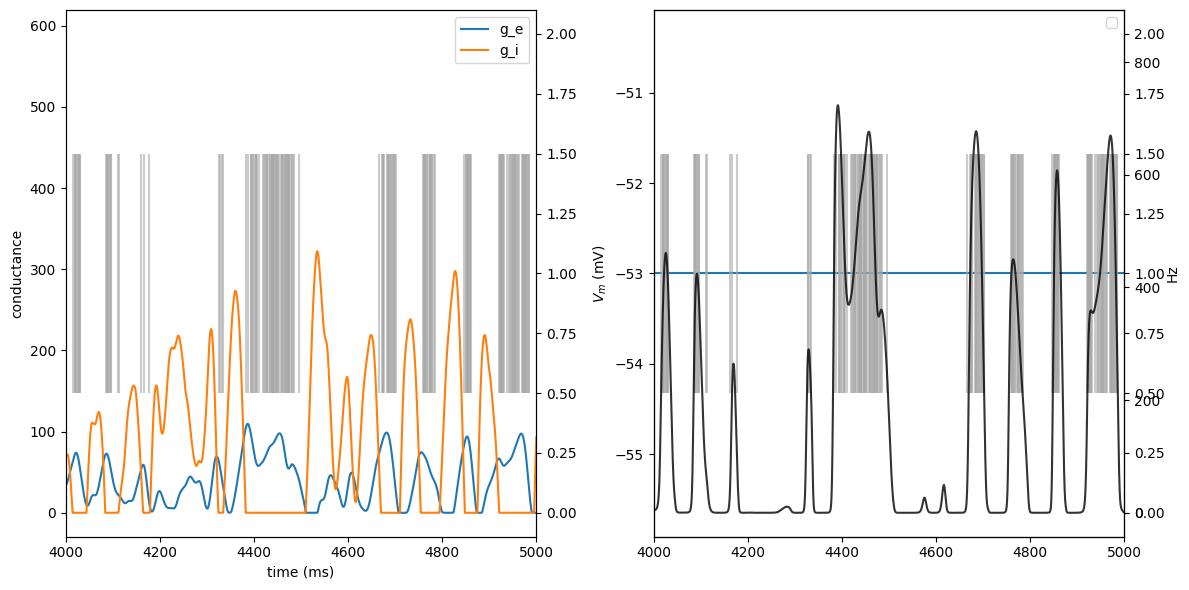

In [114]:
gs = extras['gs'].detach().cpu().numpy()
Vm = extras['V'].detach().cpu().numpy()
# X_cond = extras['X_cond'].detach().cpu().numpy()

## General shape is okay but we are off but a scale factor and not including the leak conductance!!
pltLength_bins = 70000
t_ms = np.arange(pltLength_bins)*dt*1e3 
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].plot(t_ms, gs[0:pltLength_bins,:], label=["g_e", "g_i"])
spikes = axes[0].twinx()
spikes.eventplot(spkTimes_ms_by_trial, color='darkgray', alpha=0.6)
axes[0].set_xlabel('time (ms)')
axes[0].set_ylabel('conductance')

# axes[1].plot(t_ms, Vm[:pltLength_bins])
spikes = axes[1].twinx()
spikes.eventplot(spkTimes_ms_by_trial, color='darkgray', alpha=0.6)
axes[1].axhline(-53)
axes[1].set_ylabel(r'$V_m \text{ (mV)}$')
rate_ax = axes[1].twinx()
rate_ax.plot(t_ms, Fr[0:pltLength_bins], label='Spike Rate', c='k', alpha =0.8)
rate_ax.set_ylabel("Hz")
for ax in axes:
    ax.set_xlim(4000,5000)
    ax.legend()
fig.tight_layout()
plt.show()

GT recon error (orth vs stim reconstruction): 6.719948260069941e-07


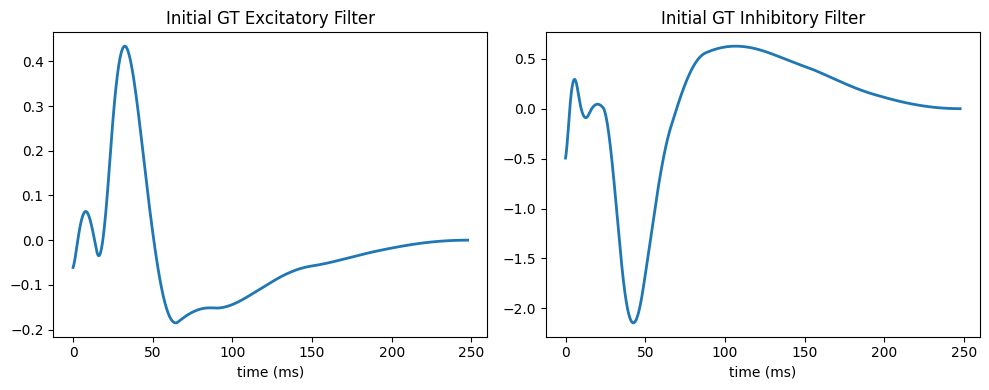

In [115]:
# Plot initial GT filters reconstructed consistently
stimBasisVectors_t = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
Borth = torch.as_tensor(B_orth, device=device, dtype=CBEM_true.B_cond.dtype)                          # [L,P]

W_true = CBEM_true.B_cond.detach()  # [D,2], currently in orth basis
P = stimBasisVectors_t.shape[1]
W_true_orth = W_true[:P, :]         # [P,2]

# Convert orth -> stim coefficients for plotting in MATLAB/stim basis
R = Borth.T @ stimBasisVectors_t    # Bstim ≈ Borth @ R
W_true_stim = torch.linalg.solve(R, W_true_orth)

# Time-domain GT filters in stim basis
f_e_from_model = stimBasisVectors_t @ W_true_stim[:, 0]   # [L]
f_i_from_model = stimBasisVectors_t @ W_true_stim[:, 1]   # [L]

# Also keep orth-basis recon for sanity
f_true_orth = Borth @ W_true_orth
f_true_stim = torch.stack([f_e_from_model, f_i_from_model], dim=1)
print('GT recon error (orth vs stim reconstruction):', float((f_true_orth - f_true_stim).norm() / f_true_orth.norm()))

# Plot initial GT filters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_ms = np.arange(f_e_from_model.shape[0]) * dt * 1e3

axes[0].plot(t_ms, f_e_from_model.detach().cpu().numpy(), lw=2)
axes[0].set_title('Initial GT Excitatory Filter')
axes[0].set_xlabel('time (ms)')

axes[1].plot(t_ms, f_i_from_model.detach().cpu().numpy(), lw=2)
axes[1].set_title('Initial GT Inhibitory Filter')
axes[1].set_xlabel('time (ms)')

plt.tight_layout()
plt.show()



## Loss and fit!

In [116]:
def poisson_nll_truncated_from_spike_bins(rate: torch.Tensor,
                                         spkTimes_bins: torch.Tensor,
                                         binsize_s: float,
                                         eps= 1e-8) -> torch.Tensor:
    """
    Truncated-Poisson / Bernoulli-per-bin likelihood.
     Based on Citi et. al 2014: product of T bernoulli trials. Works if max 1 spk/bin
    logp
    \log_p(y_{1:T}\mid \textbf{x}_{1:T}, \Theta ) = 
    \sum_{t=1}^T y_t \log(1- \exp(-\lambda_t \Delta ))-(1- y_t)\lambda_t\Delta
    
    Args:
    rate: [T] firing rate in spikes/second (Hz)
    binsize_s: seconds per bin (self.binsize_s)
    spkTimes_bins: indices (0..T-1) of bins that contain a spike (or >=1 spike)

    Log-likelihood per bin:
      ll_t = -lam_t                                  if y_t = 0
      ll_t = log(1 - exp(-lam_t))                    if y_t = 1
    where lam_t = rate_t * binsize_s  (expected count in bin)

    Returns:
      nll: scalar negative log-likelihood (sum over bins)
    """
    lam = rate * binsize_s                      # [T]
    ll = -lam                                   # default no-spike

    spk_idx = torch.as_tensor(spkTimes_bins, device=rate.device, dtype=torch.long)
    spk_idx = spk_idx[(spk_idx >= 0) & (spk_idx < lam.shape[0])]
    if spk_idx.numel() > 0:
        spk_idx = torch.unique(spk_idx)

        # log(1 - exp(-lam)) = log(-expm1(-lam)) stable for small lam
        p_spike = (-torch.expm1(-lam[spk_idx])).clamp_min(eps)  # in (0,1]
        ll_spike = torch.log(p_spike)

        ll = ll.clone()
        ll[spk_idx] = ll_spike

    return -ll.sum()

def cbem_penalized_nll(model,
                       stimulus: torch.Tensor,
                       spkTimes_bins: torch.Tensor,
                       window=None,
                       conductance_penalty=(1.0, 0.2)) -> torch.Tensor:
    """
    Penalized NLL:
      nll = truncated_poisson_nll(rate)
      + sum_c pen[c] * ||B_cond[:-1, c]||^2

    Excludes last row of B_cond (baseline term), matching JAX.
    """
    rate, _ = model(stimulus, window=window)  # calls forward
    nll = poisson_nll_truncated_from_spike_bins(rate, spkTimes_bins, model.binsize_s)

    B = model.B_cond
    if B is None:
        raise RuntimeError("model.B_cond is None. Run model once to initialize B_cond.")

    W = B[:-1, :]  # exclude baseline row
    pen = torch.as_tensor(conductance_penalty, device=W.device, dtype=W.dtype)  # [2]

    # generic form (works even if you later change #conductances)
    if pen.numel() != W.shape[1]:
        raise ValueError(f"conductance_penalty has {pen.numel()} elements but B_cond has {W.shape[1]} columns.")

    nll = nll + (pen * (W**2).sum(dim=0)).sum()
    return nll

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1480/1821305775.py:9: SyntaxWarning: invalid escape sequence '\l'
  \log_p(y_{1:T}\mid \textbf{x}_{1:T}, \Theta ) =


In [89]:
import torch
import torch.nn.functional as F

# ----------------------------
# 1) Helper: build spike-bin indices from a 0/1 vector (or counts) y[t]
# ----------------------------
def spike_bins_from_y(y: torch.Tensor):
    """
    y: [T] or [T,1] with 0/1 (or >=1) spikes per bin
    returns: 1D long tensor of indices where y>0
    """
    if y.ndim == 2:
        y = y[:, 0]
    return torch.where(y > 0)[0].to(torch.long)

# ----------------------------
# 2) A simple training loop
# ----------------------------
def train_cbem(
    model,
    X_cond: torch.Tensor,              # [T,D] design matrix (your X_full)
    spkTimes_bins: torch.Tensor,       # 1D long indices of spike bins
    *,
    lr=1e-2,
    weight_decay=0.0,                  # usually keep 0 here; we already add explicit penalty
    conductance_penalty=(1.0, 0.2),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,                  # e.g. 20000 for minibatch-in-time
    seed=0,
):
    torch.manual_seed(seed)
    device = X_cond.device

    # Ensure parameters exist (B_cond is lazy)
    with torch.no_grad():
        _ = model(X_cond[:10])  # initializes B_cond based on D

    # Optimizer only over parameters (B_cond)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Optional: simple time-minibatching by sampling a contiguous window each step
    T = X_cond.shape[0]
    loss_vals = []
    for step in range(1, n_steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)

        if window_size is None:
            window = None
            loss = cbem_penalized_nll(
                model=model,
                stimulus=X_cond,
                spkTimes_bins=spkTimes_bins,
                window=window,
                conductance_penalty=conductance_penalty,
            )
        else:
            # pick a random contiguous window [start, start+W)
            W = int(window_size)
            start = torch.randint(low=0, high=max(1, T - W), size=(1,), device=device).item()
            window = torch.arange(start, start + W, device=device, dtype=torch.long)

            # IMPORTANT: restrict spike indices to this window and convert to local indices
            spk_local = spkTimes_bins[(spkTimes_bins >= start) & (spkTimes_bins < start + W)] - start

            loss = cbem_penalized_nll(
                model=model,
                stimulus=X_cond,
                spkTimes_bins=spk_local,
                window=window,  # model slices X_cond[window]
                conductance_penalty=conductance_penalty,
            )

        loss.backward()

        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(clip_grad_norm))

        opt.step()

        if (step % print_every) == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                rate, aux = model(X_cond)
                lam = rate * model.binsize_s
                # crude sanity: mean predicted rate and mean spike prob
                mean_rate_hz = float(rate.mean())
                mean_p = float((-torch.expm1(-lam)).mean())
            loss_vals.append(loss)
            print(f"step {step:5d} | loss {float(loss):.3f} | mean rate {mean_rate_hz:.3f} Hz | mean p {mean_p:.6f}")
    return model, loss_vals

# ----------------------------
# 3) Example usage
# ----------------------------
# X_full: [T,D]
# spkTimes_bins: you already created from simulated spikes, e.g. spkTimes_bins[0]

spk_idx = torch.as_tensor(spkTimes_bins[0], device=X_full.device, dtype=torch.long)

model = CBEM(binsize_s=dt).to(device)

trained, losses = train_cbem(
    model,
    X_cond=X_full,
    spkTimes_bins=spk_idx,
    lr=1e-2,
    conductance_penalty=(1.0, 0.2),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,   # set None to train full sequence each step
)

# After training, your learned basis weights are:
B_cond_learned = trained.B_cond.detach().cpu()   # [D,2]

step     1 | loss 7973.014 | mean rate 1.469 Hz | mean p 0.000147
step   100 | loss 6147.126 | mean rate 11.839 Hz | mean p 0.001179
step   200 | loss 5066.407 | mean rate 26.527 Hz | mean p 0.002633
step   300 | loss 4477.695 | mean rate 47.577 Hz | mean p 0.004702
step   400 | loss 4198.747 | mean rate 71.364 Hz | mean p 0.007024
step   500 | loss 4075.136 | mean rate 94.806 Hz | mean p 0.009296
step   600 | loss 4032.703 | mean rate 113.935 Hz | mean p 0.011141
step   700 | loss 4015.935 | mean rate 114.569 Hz | mean p 0.011210
step   800 | loss 4004.176 | mean rate 114.431 Hz | mean p 0.011203
step   900 | loss 3995.168 | mean rate 114.593 Hz | mean p 0.011224
step  1000 | loss 3988.110 | mean rate 114.951 Hz | mean p 0.011263
step  1100 | loss 3982.632 | mean rate 115.465 Hz | mean p 0.011318
step  1200 | loss 3978.252 | mean rate 115.950 Hz | mean p 0.011369
step  1300 | loss 3974.033 | mean rate 116.083 Hz | mean p 0.011384
step  1400 | loss 3970.677 | mean rate 116.384 Hz | mea

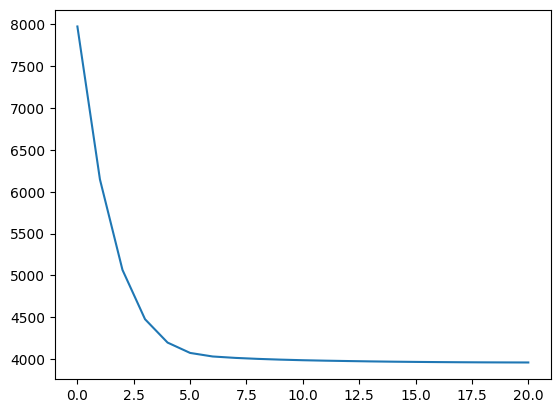

In [90]:
detached_losses = [loss.detach() for loss in losses]
plt.plot(detached_losses)

In [91]:
B = B_cond_learned          # [D,2]
W_orth = B[:-1, :]          # [P,2] learned coeffs in orth basis (drop bias row)
bias = B[-1, :]             # [2]

Borth = torch.as_tensor(B_orth, device=W_orth.device, dtype=W_orth.dtype)          # [L,P]
Bstim = torch.as_tensor(stimBasisVectors, device=W_orth.device, dtype=W_orth.dtype) # [L,P]

# Change-of-basis matrix: Bstim ≈ Borth @ R
# R = Borth.T @ Bstim                                                              # [P,P]
R = torch.linalg.lstsq(Borth, Bstim).solution
# or: R = torch.linalg.solve(Borth.T @ Borth, Borth.T @ Bstim)

# Convert learned orth-coeffs -> MATLAB/stim-basis coeffs
W_stim = torch.linalg.solve(R, W_orth)                                           # [P,2]

# Time-domain filters reconstructed in each basis (must match up to numerical error)
f_learned_orth = Borth @ W_orth                                                  # [L,2]
f_learned_stim = Bstim @ W_stim                                                  # [L,2]

recon_err = float((f_learned_orth - f_learned_stim).norm() / f_learned_orth.norm())
print('recon error (should be tiny):', recon_err)

# Keep convenient vectors for plotting
f_e_learned = f_learned_stim[:, 0]
f_i_learned = f_learned_stim[:, 1]

t_ms = torch.arange(Borth.shape[0], device=W_orth.device) * (dt * 1e3)



recon error (should be tiny): 4.4680251676254557e-07


AttributeError: 'numpy.ndarray' object has no attribute 'detach'

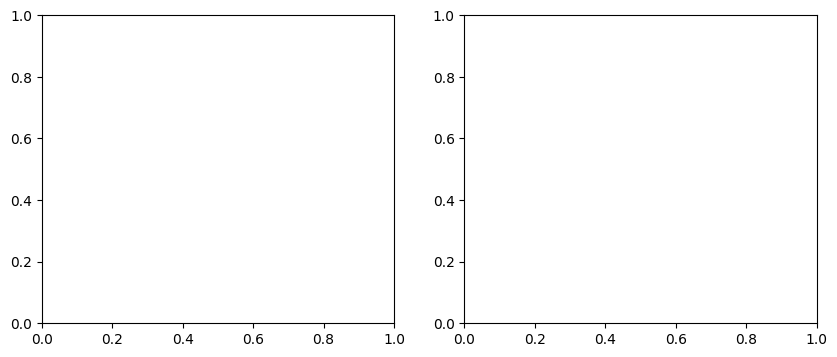

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_ms_np = t_ms.detach().cpu().numpy()

# Compare in the SAME basis (MATLAB stim basis)
axes[0].plot(t_ms_np, f_e_from_model.detach().cpu().numpy(), label='True', lw=2)
axes[0].plot(t_ms_np, f_e_learned.detach().cpu().numpy(), '--', label='learned', lw=2)
axes[0].set_title('Excitatory filter')
axes[0].set_xlabel('time (ms)')
axes[0].legend(loc='best')

axes[1].plot(t_ms_np, f_i_from_model.detach().cpu().numpy(), label='True', lw=2)
axes[1].plot(t_ms_np, f_i_learned.detach().cpu().numpy(), '--', label='Learned', lw=2)
axes[1].set_title('Inhibitory filter')
axes[1].set_xlabel('time (ms)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()



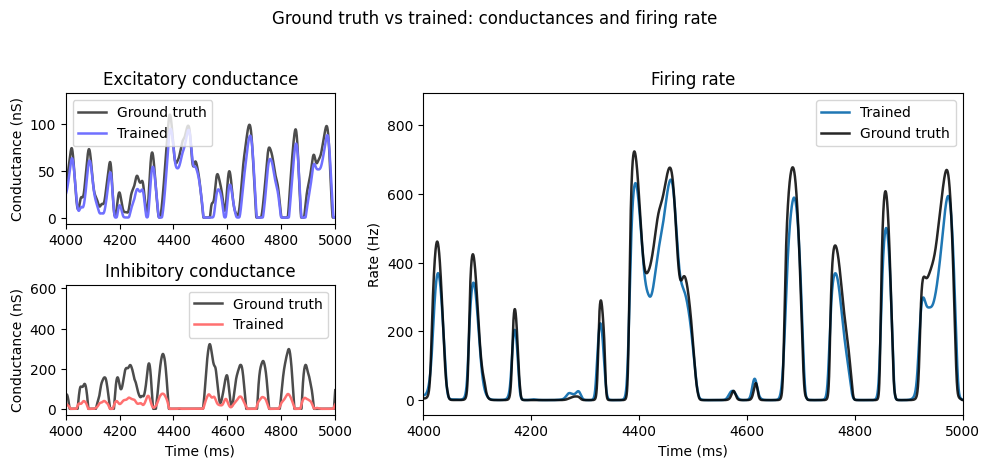

In [136]:
trained.eval()
Fr_train, extras_trained = trained(X_full, window=None)
Fr_train = Fr_train.detach().cpu().numpy()

gs_train = extras_trained['gs'].detach().cpu().numpy()
Vm = extras_trained['V'].detach().cpu().numpy()

# Compare trained vs ground-truth conductances and firing rate
pltLength_bins = min(70000, gs_train.shape[0], gs.shape[0], Fr_train.shape[0], Fr.shape[0])
t_ms = np.arange(pltLength_bins) * dt * 1e3

fig = plt.figure(figsize=(10, 4.5))
Gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1, 2], height_ratios=[1, 1])

g_Exc = fig.add_subplot(Gs[0, 0])
g_Inh = fig.add_subplot(Gs[1, 0])
rate_ax = fig.add_subplot(Gs[:, 1])

cmap_bwr = plt.get_cmap('bwr')
# Excitation: blue tones; inhibition: red tones
exc_trained_c = cmap_bwr(0.22)
exc_true_c = cmap_bwr(0.10)
inh_trained_c = cmap_bwr(0.78)
inh_true_c = cmap_bwr(0.90)

g_Exc.plot(t_ms, gs[:pltLength_bins, 0], label='Ground truth', lw=1.8, alpha=0.70, color='k')
g_Exc.plot(t_ms, gs_train[:pltLength_bins, 0], label='Trained', lw=1.8, color=exc_trained_c)
g_Exc.set_title('Excitatory conductance')
g_Exc.set_ylabel('Conductance (nS)')

g_Inh.plot(t_ms, gs[:pltLength_bins, 1], label='Ground truth', lw=1.8, alpha=0.70, color='k')
g_Inh.plot(t_ms, gs_train[:pltLength_bins, 1], label='Trained', lw=1.8, color=inh_trained_c)
g_Inh.set_title('Inhibitory conductance')
g_Inh.set_xlabel('Time (ms)')
g_Inh.set_ylabel('Conductance (nS)')

rate_ax.plot(t_ms, Fr_train[:pltLength_bins], label='Trained', lw=1.8)
rate_ax.plot(t_ms, Fr[:pltLength_bins], label='Ground truth', lw=1.8, alpha=0.85, c='k')
rate_ax.set_title('Firing rate')
rate_ax.set_xlabel('Time (ms)')
rate_ax.set_ylabel('Rate (Hz)')

# Use one x-range for all panels
xlim_ms = (4000.0, 5000.0)
if t_ms.size > 0:
    lo = max(float(t_ms[0]), xlim_ms[0])
    hi = min(float(t_ms[-1]), xlim_ms[1])
    if hi <= lo:
        lo, hi = float(t_ms[0]), float(t_ms[-1])
    for ax in (g_Exc, g_Inh, rate_ax):
        ax.set_xlim(lo, hi)
        ax.legend(loc='best')
        # ax.grid(alpha=0.25, linestyle='--', linewidth=0.7)

fig.suptitle('Ground truth vs trained: conductances and firing rate', y=1.03)
fig.tight_layout()
plt.show()


## To do:

- Initial Conditions!